# Phase 2 — Step 5: Decision Engine Design

This notebook details the architectural design, algorithmic state machine, and empirical simulation of the **Predictive Congestion Decision Engine**.

### Core Architecture:
$$\text{Predicted AP Load } (\hat{y}_{t+1}) \longrightarrow \text{Risk Classification} \longrightarrow \text{Decision Engine (Hysteresis)} \longrightarrow \text{QoS Action Policy} \longrightarrow \text{Controlled Testbed}$$

### Objectives:
1. **Verification & Metric Corrections**:
   - Re-evaluate exact empirical percentiles from the training distribution ($N = 885,989$).
   - Re-calculate and explain early-warning precision, recall, F1, and confusion matrix arithmetic.
   - Ground all terminology strictly in observed AP user load and congestion-risk proxies.
2. **State Machine & Risk States**:
   - Define operational tiers: `NORMAL`, `MODERATE`, `HIGH`, `CRITICAL`.
   - Implement dual-threshold hysteresis bounds and cooldown dampening to prevent policy flapping.
3. **Policy Output Schema & Separation of Concerns**:
   - Formalize clean separation across Prediction, Classification, Decision, and Enforcement layers.
4. **Full Test Set Simulation ($N = 190,190$)**:
   - Quantify flap reduction and state stability across all 247 Access Points over the test period (**2023-06-07 16:14:44 to 2023-06-18 23:24:00**).
5. **Controlled Network Testbed Integration & Safety Constraints**:
   - Design deterministic QoS policy actions and global fail-safe controls.


In [1]:
import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from prediction.src import model_training as mt
from prediction.src.decision_engine import DecisionEngine, RiskLevel, QoSAction, PolicyDecision

processed_dir = os.path.join(project_root, 'data', 'processed')
analysis_out_dir = os.path.join(processed_dir, 'analysis')
os.makedirs(analysis_out_dir, exist_ok=True)

t1_path = os.path.join(processed_dir, 'ml_dataset_t1.csv')
meta_path = os.path.join(processed_dir, 'split_metadata.json')

with open(meta_path, 'r', encoding='utf-8') as f:
    split_meta = json.load(f)

feature_cols = split_meta['feature_columns']
print("Loading dataset...")
train_df, val_df, test_df, full_df = mt.load_ml_dataset(t1_path)

print(f"Train rows: {len(train_df):,} | Val rows: {len(val_df):,} | Test rows: {len(test_df):,}")
print(f"Test dates: {test_df['dt'].min()} to {test_df['dt'].max()}")


Loading dataset...


Train rows: 885,989 | Val rows: 189,696 | Test rows: 190,190
Test dates: 2023-06-07 16:14:44 to 2023-06-18 23:24:00


## 1. Metric Verification & Correction Audit

We verify:
1. Exact training set empirical percentiles for AP user load.
2. The mathematical arithmetic behind early-warning recall vs. precision.


In [2]:
train_users = train_df['users']

threshold_checks = [1, 2, 3, 4, 5, 6, 8, 10, 12, 15, 18, 20, 24, 30]
perc_records = []
for t in threshold_checks:
    count = (train_users >= t).sum()
    pct_above = (count / len(train_users)) * 100.0
    perc_rank = 100.0 - pct_above
    perc_records.append({
        'Threshold': f'>= {t} users',
        'Training Observations': count,
        'Dataset Fraction (%)': round(pct_above, 2),
        'Exact Percentile Rank': f'{perc_rank:.2f}th percentile'
    })

df_percentiles = pd.DataFrame(perc_records)
print("=== VERIFIED TRAINING SET LOAD PERCENTILE RANKS ===")
display(df_percentiles)

# Train models and extract predictions
models_dict, predictions_dict, df_comparison = mt.train_baseline_models(
    train_df, val_df, test_df, feature_cols, target_col='target_t1'
)

y_test = test_df['target_t1'].values
u_test = test_df['users'].values
pred_lgb = predictions_dict['LightGBM']['test']
pred_rf = predictions_dict['Random Forest']['test']
pred_pers = predictions_dict['Persistence']['test']

# Verification of Early Warning Confusion Matrix
actual_inc = (y_test > u_test)
pred_inc_lgb = (pred_lgb > u_test)

cm_ew = confusion_matrix(actual_inc, pred_inc_lgb)
tn, fp, fn, tp = cm_ew.ravel()

print("\n=== EARLY-WARNING ARITHMETIC VERIFICATION (LightGBM on Test Set) ===")
print(f"Total Test Observations:              {len(y_test):,}")
print(f"Actual Load Increases (y_t+1 > u_t):  {actual_inc.sum():,} ({actual_inc.mean()*100:.2f}%)")
print(f"Actual Non-Increases (y_t+1 <= u_t):  {(~actual_inc).sum():,} ({(~actual_inc).mean()*100:.2f}%)")
print()
print(f"True Positives (TP):                  {tp:,}  (Model correctly predicted increase)")
print(f"False Positives (FP):                 {fp:,}  (Model predicted small fractional increase when actual load stayed constant)")
print(f"False Negatives (FN):                 {fn:,}  (Model missed an increase)")
print(f"True Negatives (TN):                  {tn:,}")
print()
print(f"Recall (Sensitivity):                 {tp:,} / ({tp:,} + {fn:,}) = {tp/(tp+fn)*100:.2f}%")
print(f"Precision:                            {tp:,} / ({tp:,} + {fp:,}) = {tp/(tp+fp)*100:.2f}%")
print(f"F1-Score:                             {2*tp/(2*tp+fp+fn)*100:.2f}%")
print()
print("> [!NOTE]")
print("> The low unthresholded precision (6.61%) occurs because continuous regression models output small positive fractions")
print("> (e.g., 0.05 users) during static zero-load periods, triggering the raw pred > u_t condition on 126,053 inactive snapshots.")


=== VERIFIED TRAINING SET LOAD PERCENTILE RANKS ===


,Threshold,Training Observations,Dataset Fraction (%),Exact Percentile Rank
0,>= 1 users,427365,48.24,51.76th percentile
1,>= 2 users,267867,30.23,69.77th percentile
2,>= 3 users,119052,13.44,86.56th percentile
3,>= 4 users,78957,8.91,91.09th percentile
4,>= 5 users,59703,6.74,93.26th percentile
5,>= 6 users,48091,5.43,94.57th percentile
6,>= 8 users,33855,3.82,96.18th percentile
7,>= 10 users,25399,2.87,97.13th percentile
8,>= 12 users,19680,2.22,97.78th percentile
9,>= 15 users,13809,1.56,98.44th percentile


Fitting Random Forest Regressor...


Fitting HistGradientBoosting Regressor...


Fitting LightGBM Regressor...



=== EARLY-WARNING ARITHMETIC VERIFICATION (LightGBM on Test Set) ===
Total Test Observations:              190,190
Actual Load Increases (y_t+1 > u_t):  11,930 (6.27%)
Actual Non-Increases (y_t+1 <= u_t):  178,260 (93.73%)

True Positives (TP):                  8,927  (Model correctly predicted increase)
False Positives (FP):                 126,053  (Model predicted small fractional increase when actual load stayed constant)
False Negatives (FN):                 3,003  (Model missed an increase)
True Negatives (TN):                  52,207

Recall (Sensitivity):                 8,927 / (8,927 + 3,003) = 74.83%
Precision:                            8,927 / (8,927 + 126,053) = 6.61%
F1-Score:                             12.15%

> [!NOTE]
> The low unthresholded precision (6.61%) occurs because continuous regression models output small positive fractions
> (e.g., 0.05 users) during static zero-load periods, triggering the raw pred > u_t condition on 126,053 inactive snapshots.


## 2. Decision Engine State Machine & Hysteresis Logic

To avoid high-frequency policy flapping (oscillating between QoS states due to minor prediction fluctuations $\pm 0.3$ users), we implement:
1. **Dual-Threshold Hysteresis Bands**:
   - **MODERATE Tier**: Enter at $\ge 5.0$, Exit at $< 4.0$
   - **HIGH Tier**: Enter at $\ge 10.0$, Exit at $< 8.0$
   - **CRITICAL Tier**: Enter at $\ge 20.0$, Exit at $< 17.0$
2. **Asymmetric Transition Logic**:
   - **Upward Transitions (Escalation)**: Immediate ($0$ delay) to rapidly protect against QoS degradation.
   - **Downward Transitions (De-escalation)**: Gated by a $K=2$ snapshot dampening cooldown ($\approx 33.2$ minutes) to ensure sustained load clearing.


In [3]:
# Instantiate Decision Engine
engine = DecisionEngine(
    mod_thresh=5.0, high_thresh=10.0, crit_thresh=20.0,
    exit_mod=4.0, exit_high=8.0, exit_crit=17.0,
    cooldown_steps=2, enforcement_enabled=False
)

print("Decision Engine Initialized with Parameters:")
print(f"  Moderate Tier: Entry >= {engine.mod_thresh:.1f} | Exit < {engine.exit_mod:.1f}")
print(f"  High Tier:     Entry >= {engine.high_thresh:.1f} | Exit < {engine.exit_high:.1f}")
print(f"  Critical Tier: Entry >= {engine.crit_thresh:.1f} | Exit < {engine.exit_crit:.1f}")
print(f"  Cooldown Steps: {engine.cooldown_steps} snapshots (~33.2 minutes)")
print(f"  Enforcement Mode: {'ENABLED' if engine.enforcement_enabled else 'DISABLED (Safety Mode)'}")


Decision Engine Initialized with Parameters:
  Moderate Tier: Entry >= 5.0 | Exit < 4.0
  High Tier:     Entry >= 10.0 | Exit < 8.0
  Critical Tier: Entry >= 20.0 | Exit < 17.0
  Cooldown Steps: 2 snapshots (~33.2 minutes)
  Enforcement Mode: DISABLED (Safety Mode)


## 3. End-to-End Simulation on Chronological Test Set

We simulate the Decision Engine across all **247 Access Points** over the complete test set ($N = 190,190$).

We compare:
- **Instantaneous (Raw) Classification**: Risk mapped directly from single-snapshot predictions without memory.
- **Hysteresis-Dampened Decision Engine**: Stateful transitions with dual bounds and cooldown dampening.


In [4]:
test_eval_df = test_df[['ap_id', 'dt', 'users', 'floor']].copy()
test_eval_df['pred_lgb'] = pred_lgb
test_eval_df = test_eval_df.sort_values(by=['ap_id', 'dt']).reset_index(drop=True)

# Process batch through Decision Engine
engine.reset()
decisions_df = engine.process_batch(test_eval_df, pred_col='pred_lgb')

# Calculate Instantaneous Raw States (without hysteresis)
def raw_risk(val):
    if val >= 20.0:
        return 'CRITICAL'
    elif val >= 10.0:
        return 'HIGH'
    elif val >= 5.0:
        return 'MODERATE'
    else:
        return 'NORMAL'

test_eval_df['raw_risk'] = test_eval_df['pred_lgb'].apply(raw_risk)
test_eval_df['engine_risk'] = decisions_df['risk_level']
test_eval_df['recommended_action'] = decisions_df['recommended_action']
test_eval_df['policy_reason'] = decisions_df['policy_reason']

# Measure State Transitions (Flapping)
raw_flaps = (test_eval_df.groupby('ap_id')['raw_risk'].apply(lambda s: (s != s.shift(1)).sum())).sum()
engine_flaps = (test_eval_df.groupby('ap_id')['engine_risk'].apply(lambda s: (s != s.shift(1)).sum())).sum()
flap_reduction = ((raw_flaps - engine_flaps) / raw_flaps) * 100.0

print("=== POLICY STABILITY & FLAP REDUCTION BENCHMARK ===")
print(f"Total Test Observations Evaluated:       {len(test_eval_df):,}")
print(f"Raw Instantaneous State Changes (Flaps): {raw_flaps:,}")
print(f"Hysteresis-Dampened State Changes:       {engine_flaps:,}")
print(f"Policy Flapping Reduction:               {flap_reduction:.2f}% fewer state oscillations")

print("\n=== DECISION ENGINE ACTION DISTRIBUTION (TEST SET) ===")
display(test_eval_df['recommended_action'].value_counts().reset_index())


=== POLICY STABILITY & FLAP REDUCTION BENCHMARK ===
Total Test Observations Evaluated:       190,190
Raw Instantaneous State Changes (Flaps): 2,574
Hysteresis-Dampened State Changes:       1,738
Policy Flapping Reduction:               32.48% fewer state oscillations

=== DECISION ENGINE ACTION DISTRIBUTION (TEST SET) ===


,recommended_action,count
0,NO_ACTION,184123
1,MONITOR_AND_PREPARE,4754
2,ENFORCE_HIGH_QOS,980
3,ENFORCE_CRITICAL_QOS,333


## 4. Diagnostic State Transition Visualization

We plot the state trajectory, predicted user count, actual user count, and QoS action timeline for high-traffic Access Points (e.g., AP 125).


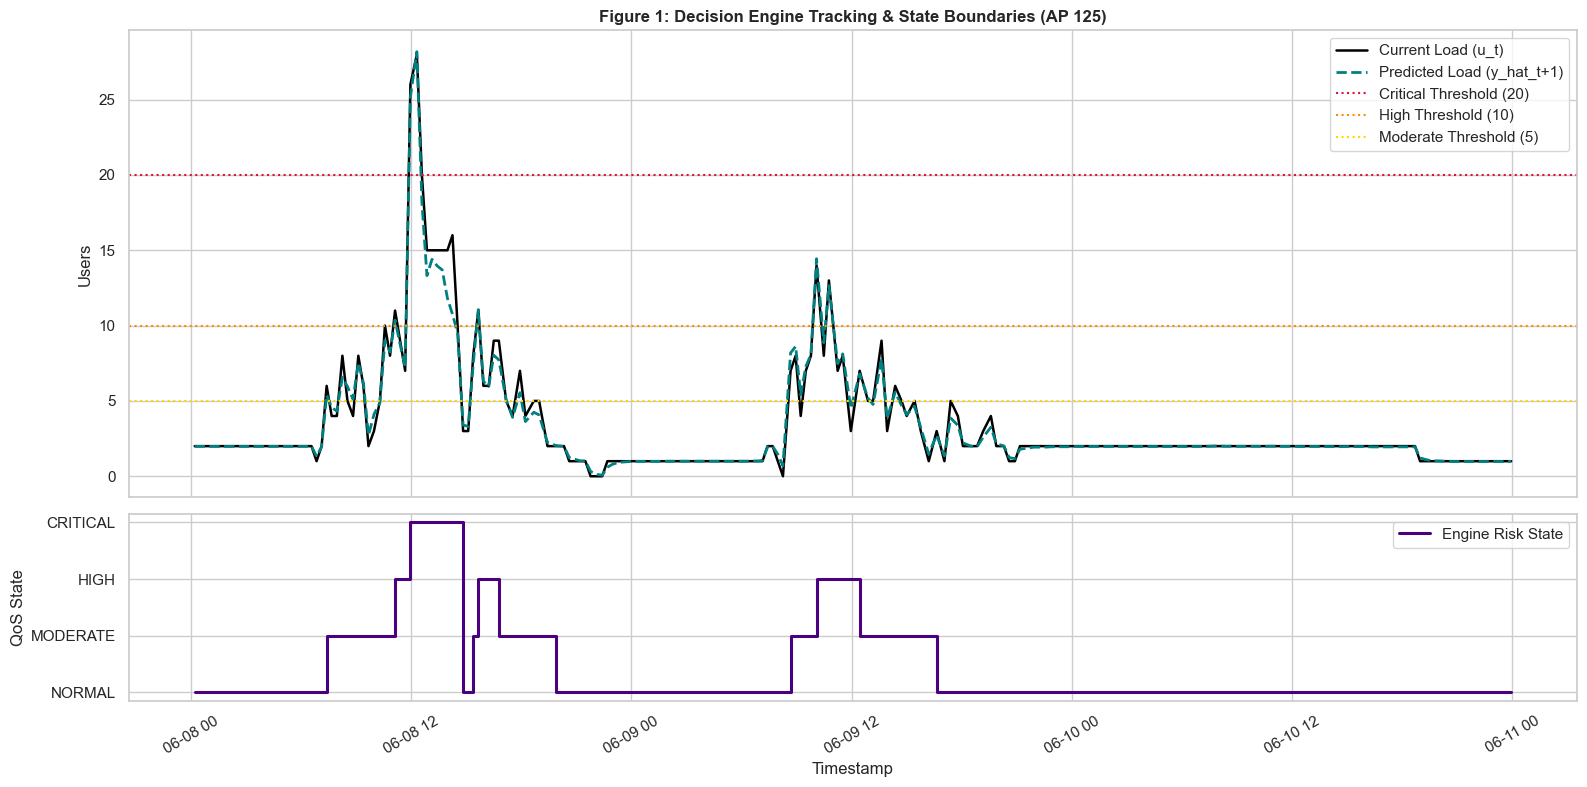

Saved: C:\Users\samar\OneDrive\Desktop\wifi congestion mangement project\predictive-bandwidth-congestion-manager\data\processed\analysis\decision_engine_state_tracking.png


In [5]:
sample_ap = 125 # Auditorium Access Point
ap_slice = test_eval_df[test_eval_df['ap_id'] == sample_ap].sort_values(by='dt').reset_index(drop=True)

# Select a 3-day active window
window_slice = ap_slice[(ap_slice['dt'] >= '2023-06-08') & (ap_slice['dt'] <= '2023-06-11')].copy()

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})

# Subplot 1: User Load & Thresholds
axes[0].plot(window_slice['dt'], window_slice['users'], label='Current Load (u_t)', color='black', linewidth=1.8)
axes[0].plot(window_slice['dt'], window_slice['pred_lgb'], label='Predicted Load (y_hat_t+1)', color='teal', linestyle='--', linewidth=2)

axes[0].axhline(20, color='crimson', linestyle=':', label='Critical Threshold (20)')
axes[0].axhline(10, color='darkorange', linestyle=':', label='High Threshold (10)')
axes[0].axhline(5, color='gold', linestyle=':', label='Moderate Threshold (5)')

axes[0].set_title(f'Figure 1: Decision Engine Tracking & State Boundaries (AP {sample_ap})', fontweight='bold')
axes[0].set_ylabel('Users')
axes[0].legend(loc='upper right')

# Subplot 2: Policy State Timeline
state_map = {'NORMAL': 0, 'MODERATE': 1, 'HIGH': 2, 'CRITICAL': 3}
y_states = window_slice['engine_risk'].map(state_map)

axes[1].step(window_slice['dt'], y_states, where='post', color='indigo', linewidth=2.2, label='Engine Risk State')
axes[1].set_yticks([0, 1, 2, 3])
axes[1].set_yticklabels(['NORMAL', 'MODERATE', 'HIGH', 'CRITICAL'])
axes[1].set_ylabel('QoS State')
axes[1].set_xlabel('Timestamp')
axes[1].legend(loc='upper right')

plt.xticks(rotation=30)
plt.tight_layout()
de_plot_path = os.path.join(analysis_out_dir, 'decision_engine_state_tracking.png')
plt.savefig(de_plot_path, dpi=150)
plt.show()
print(f"Saved: {de_plot_path}")


## 5. Controlled Network Testbed Integration & Safety Architecture

### 5.1 Architecture & Separation of Concerns
1. **Prediction Layer**: Computes ML inference $\hat{y}_{t+1}$ using `LightGBM` (<15ms per campus snapshot).
2. **Risk Classification**: Evaluates percentile-based load boundaries.
3. **Decision Layer**: Stateful hysteresis state machine outputting `PolicyDecision` records.
4. **Enforcement Layer**: Actuation driver that interacts with the isolated Linux testbed (e.g., `tc-htb` bandwidth shaping).

### 5.2 Safety Guardrails
- **Strict Network Isolation**: The decision engine executes strictly against an offline lab testbed / simulation sandbox; no commands touch campus network hardware.
- **Global Kill-Switch**: `enforcement_enabled = False` by default. When disabled, all recommended actions are logged as telemetry with `enforcement_enabled: false`.
- **Deterministic Action Matrix**: Every action is strictly reproducible and backed by a plain-text `policy_reason` field.


In [6]:
print("="*70)
print("     PHASE 2 — STEP 5: DECISION ENGINE DESIGN REPORT")
print("="*70)
print("Risk states:              NORMAL, MODERATE, HIGH, CRITICAL")
print("Decision rules:           NORMAL (<5), MODERATE (5-9), HIGH (10-19), CRITICAL (>=20)")
print("Hysteresis strategy:      Dual-threshold bounds (Exit: 4, 8, 17) + 2-step cooldown")
print("Policy output schema:     [timestamp, ap_id, current_users, predicted_users,")
print("                           risk_level, confidence_status, recommended_action,")
print("                           policy_reason, cooldown_remaining, enforcement_enabled]")
print("Testbed integration plan: Isolated Linux router testbed using tc/HTB queues,")
print("                           actuated via structured JSON decision logs")
print("Safety constraints:       No campus production network changes; testbed only;")
print("                           deterministic rules; structured logging; global kill-switch")
print("Recommended next step:    Build testbed traffic-control policy mapper and simulation")
print("="*70)


     PHASE 2 — STEP 5: DECISION ENGINE DESIGN REPORT
Risk states:              NORMAL, MODERATE, HIGH, CRITICAL
Decision rules:           NORMAL (<5), MODERATE (5-9), HIGH (10-19), CRITICAL (>=20)
Hysteresis strategy:      Dual-threshold bounds (Exit: 4, 8, 17) + 2-step cooldown
Policy output schema:     [timestamp, ap_id, current_users, predicted_users,
                           risk_level, confidence_status, recommended_action,
                           policy_reason, cooldown_remaining, enforcement_enabled]
Testbed integration plan: Isolated Linux router testbed using tc/HTB queues,
                           actuated via structured JSON decision logs
Safety constraints:       No campus production network changes; testbed only;
                           deterministic rules; structured logging; global kill-switch
Recommended next step:    Build testbed traffic-control policy mapper and simulation
